In [1]:
!pip install -q --upgrade pip
!pip install -q kaggle pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 67.6 MB/s eta 0:00:00


In [5]:
import os
import json
from pathlib import Path
from google.colab import userdata, drive

drive.mount("/content/drive")
RAW_BACKUP = Path("/content/drive/MyDrive/energy-forecast/raw")

kaggle_credentials = json.load(open('/content/kaggle.json'))
os.environ['KAGGLE_USERNAME'] = kaggle_credentials['username']
os.environ['KAGGLE_KEY'] = kaggle_credentials['key']
!kaggle datasets download -d jeanmidev/smart-meters-in-london -p /content/data --unzip
!mkdir -p /content/drive/MyDrive/energy-forecast
!cp -r /content/data "$RAW_BACKUP"

DATA = Path("/content/data")
for p in sorted(DATA.iterdir()):
    print(f"{p.name:40s} {p.stat().st_size/1e6:>10.1f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset URL: https://www.kaggle.com/datasets/jeanmidev/smart-meters-in-london
License(s): ODbL-1.0
100% 1.17G/1.17G [00:10<00:00, 122MB/s] 

Downloaded from Kaggle + backed up to Drive
acorn_details.csv                               0.1 MB
daily_dataset                                   0.0 MB
daily_dataset.csv                             351.8 MB
darksky_parameters_documentation.html           0.1 MB
halfhourly_dataset                              0.0 MB
hhblock_dataset                                 0.0 MB
informations_households.csv                     0.2 MB
uk_bank_holidays.csv                            0.0 MB
weather_daily_darksky.csv                       0.3 MB
weather_hourly_darksky.csv                      2.0 MB


In [9]:
import pandas as pd

block_files = sorted(DATA.glob("hhblock_dataset/hhblock_dataset/block_*.csv"))
if not block_files:
    block_files = sorted(DATA.glob("halfhourly_dataset/halfhourly_dataset/block_*.csv"))

print(f"Block files: {len(block_files)}")
print(block_files[0].relative_to(DATA))

sample = pd.read_csv(block_files[0])
print(sample.shape)
print(sample.dtypes)
sample.head(10)

Block files: 112
hhblock_dataset/hhblock_dataset/block_0.csv
(25286, 50)
LCLid     object
day       object
hh_0     float64
hh_1     float64
hh_2     float64
hh_3     float64
hh_4     float64
hh_5     float64
hh_6     float64
hh_7     float64
hh_8     float64
hh_9     float64
hh_10    float64
hh_11    float64
hh_12    float64
hh_13    float64
hh_14    float64
hh_15    float64
hh_16    float64
hh_17    float64
hh_18    float64
hh_19    float64
hh_20    float64
hh_21    float64
hh_22    float64
hh_23    float64
hh_24    float64
hh_25    float64
hh_26    float64
hh_27    float64
hh_28    float64
hh_29    float64
hh_30    float64
hh_31    float64
hh_32    float64
hh_33    float64
hh_34    float64
hh_35    float64
hh_36    float64
hh_37    float64
hh_38    float64
hh_39    float64
hh_40    float64
hh_41    float64
hh_42    float64
hh_43    float64
hh_44    float64
hh_45    float64
hh_46    float64
hh_47    float64
dtype: object


,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,1.164,0.249,0.225,0.258,0.260,0.334,0.299,0.236,0.241,0.237
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.966,0.172,0.192,0.228,0.203,0.211,0.188,0.213,0.157,0.202
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.223,0.075,0.230,0.208,0.265,0.377,0.327,0.277,0.288,0.256
5,MAC000002,2012-10-18,0.288,0.259,0.291,0.238,0.170,0.116,0.165,0.112,...,0.897,0.332,0.775,0.716,0.614,0.219,0.178,0.193,0.166,0.162
6,MAC000002,2012-10-19,0.165,0.154,0.173,0.114,0.128,0.082,0.133,0.074,...,0.315,0.216,0.822,0.322,0.213,0.296,0.226,0.269,0.190,0.239
7,MAC000002,2012-10-20,0.200,0.229,0.192,0.217,0.180,0.139,0.097,0.120,...,0.504,0.637,0.686,0.581,0.585,0.562,0.536,0.429,0.426,0.386
8,MAC000002,2012-10-21,0.390,0.348,0.372,0.341,0.370,0.285,0.272,0.268,...,0.829,0.720,0.701,0.873,0.903,0.813,0.548,0.402,0.446,0.390
9,MAC000002,2012-10-22,0.431,0.401,0.294,0.359,0.305,0.353,0.323,0.336,...,1.126,0.284,0.282,0.441,0.705,0.393,0.372,0.215,0.315,0.216


In [13]:

import numpy as np

hh_cols = [f"hh_{i}" for i in range(48)]
melted = sample.melt(
    id_vars=["LCLid", "day"],
    value_vars=hh_cols,
    var_name="half_hour",
    value_name="energy(kWh/hh)"
)

melted["hh_index"] = melted["half_hour"].str.split("_").str[1].astype(int)
melted["hours"] = melted["hh_index"] // 2
melted["minutes"] = (melted["hh_index"] % 2) * 30

melted["tstp"] = (
    melted["day"]
    + " "
    + melted["hours"].astype(str).str.zfill(2)
    + ":"
    + melted["minutes"].astype(str).str.zfill(2)
    + ":00"
)

sample_long = melted[["LCLid", "tstp", "energy(kWh/hh)"]].copy()
tstp = sample_long["tstp"].astype(str)
print("Constructed tstp examples:", tstp.head(2).tolist())

parsed = pd.to_datetime(tstp, errors="coerce", utc=True)
n_bad = int(parsed.isna().sum())
print(f"Unparseable timestamps in processed block 0: {n_bad:,} / {len(tstp):,}")

Constructed tstp examples: ['2012-10-13 00:00:00', '2012-10-14 00:00:00']
Unparseable timestamps in processed block 0: 0 / 1,213,728


In [14]:
coverage = []
hh_cols = [f"hh_{i}" for i in range(48)]

for i, path in enumerate(block_files):
    df = pd.read_csv(path)

    days = pd.to_datetime(df["day"], errors="coerce")

    missing_vals = df[hh_cols].apply(pd.to_numeric, errors="coerce").isna().sum().sum()

    coverage.append({
        "block": path.name,
        "rows": len(df) * 48,
        "households": df["LCLid"].nunique(),
        "start": days.min(),
        "end": days.max() + pd.Timedelta(hours=23, minutes=30),
        "unparsed_ts": int(days.isna().sum() * 48),
        "missing_energy": int(missing_vals),
    })
    if (i + 1) % 25 == 0:
        print(f"{i + 1}/{len(block_files)} blocks scanned")

cov = pd.DataFrame(coverage)
print(cov[["rows", "households", "unparsed_ts", "missing_energy"]].sum())
print("\nGlobal range:", cov["start"].min(), "→", cov["end"].max())
cov.head()

25/112 blocks scanned
50/112 blocks scanned
75/112 blocks scanned
100/112 blocks scanned
rows              166528896
households             5560
unparsed_ts               0
missing_energy         5486
dtype: int64

Global range: 2011-11-24 00:00:00 → 2014-02-27 23:30:00


,block,rows,households,start,end,unparsed_ts,missing_energy
0,block_0.csv,1213728,50,2011-12-04,2014-02-27 23:30:00,0,50
1,block_1.csv,1499664,50,2011-12-22,2014-02-27 23:30:00,0,50
2,block_10.csv,1510944,50,2012-01-24,2014-02-27 23:30:00,0,48
3,block_100.csv,1508160,50,2012-02-03,2014-02-27 23:30:00,0,49
4,block_101.csv,1423488,50,2011-11-24,2014-02-27 23:30:00,0,50


In [15]:
expected_slots = int(((cov["end"].max() - cov["start"].min()).total_seconds() // 1800) + 1)
total_households = int(cov["households"].sum())
total_rows = int(cov["rows"].sum())

print(f"Unique households (sum over blocks): {total_households:,}")
print(f"Total readings:                     {total_rows:,}")
print(f"Approx. panel completeness:         {total_rows / (expected_slots * total_households):.1%}")
print("(Households joined/left during the trial, so < 100% is expected.)")

Unique households (sum over blocks): 5,560
Total readings:                     166,528,896
Approx. panel completeness:         75.5%
(Households joined/left during the trial, so < 100% is expected.)


In [16]:
weather = pd.read_csv(DATA / "weather_hourly_darksky.csv")
print(weather.shape)
print(weather.dtypes)
weather.head(3)

(21165, 12)
visibility             float64
windBearing              int64
temperature            float64
time                    object
dewPoint               float64
pressure               float64
apparentTemperature    float64
windSpeed              float64
precipType              object
icon                    object
humidity               float64
summary                 object
dtype: object


,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy


In [17]:
wt = pd.to_datetime(weather["time"], errors="coerce", utc=True)
print("Weather range:", wt.min(), "→", wt.max())
print("Missing values:")
print(weather.isna().sum()[weather.isna().sum() > 0])

Weather range: 2011-11-01 00:00:00+00:00 → 2014-03-31 22:00:00+00:00
Missing values:
pressure    13
dtype: int64


In [18]:
households = pd.read_csv(DATA / "informations_households.csv")
print(households.shape)
print(households.columns.tolist())
print()
for col in ["stdorToU", "Acorn_grouped"]:
    print(col, ":", households[col].value_counts().to_dict())

(5566, 5)
['LCLid', 'stdorToU', 'Acorn', 'Acorn_grouped', 'file']

stdorToU : {'Std': 4443, 'ToU': 1123}
Acorn_grouped : {'Affluent': 2192, 'Adversity': 1816, 'Comfortable': 1507, 'ACORN-U': 49, 'ACORN-': 2}


In [19]:
holidays = pd.read_csv(DATA / "uk_bank_holidays.csv")
print(holidays.shape)
holidays.head(5)

(25, 2)


,Bank holidays,Type
0,2012-12-26,Boxing Day
1,2012-12-25,Christmas Day
2,2012-08-27,Summer bank holiday
3,2012-05-06,Queen?s Diamond Jubilee (extra bank holiday)
4,2012-04-06,Spring bank holiday (substitute day)


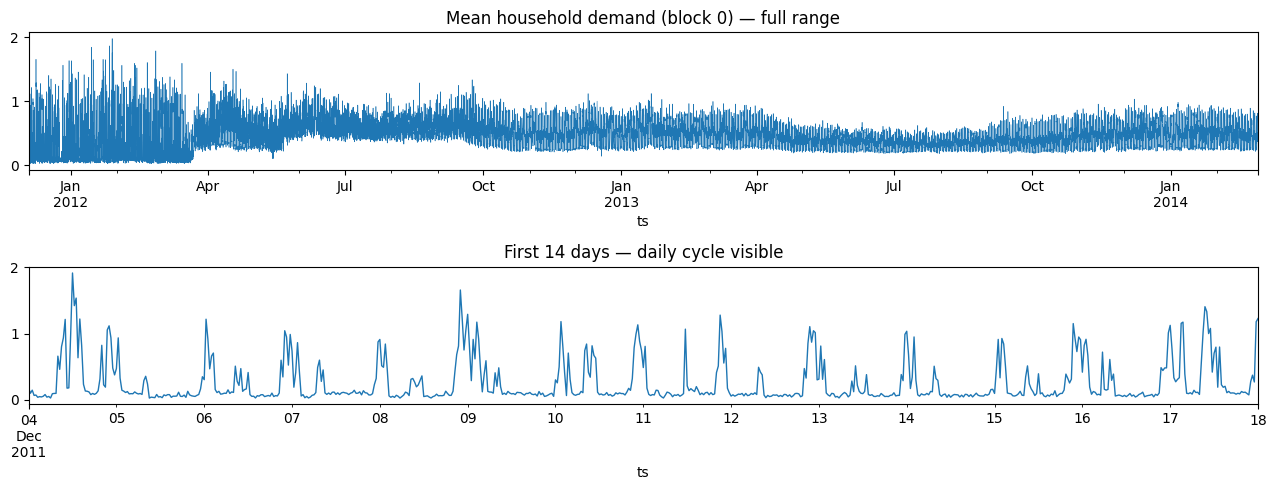

In [20]:
import matplotlib.pyplot as plt

# Reshape sample to long format for visualization
hh_cols = [f"hh_{i}" for i in range(48)]
df0 = sample.melt(
    id_vars=["LCLid", "day"],
    value_vars=hh_cols,
    var_name="half_hour",
    value_name="energy(kWh/hh)"
)
df0["hh_index"] = df0["half_hour"].str.split("_").str[1].astype(int)
df0["hours"] = df0["hh_index"] // 2
df0["minutes"] = (df0["hh_index"] % 2) * 30
df0["tstp"] = df0["day"] + " " + df0["hours"].astype(str).str.zfill(2) + ":" + df0["minutes"].astype(str).str.zfill(2) + ":00"

df0["ts"] = pd.to_datetime(df0["tstp"], errors="coerce", utc=True)
df0["energy"] = pd.to_numeric(df0["energy(kWh/hh)"], errors="coerce")
agg = df0.groupby("ts")["energy"].mean().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 5))
agg.plot(ax=axes[0], lw=0.4, title="Mean household demand (block 0) — full range")
agg.loc[agg.index[0]:agg.index[0] + pd.Timedelta(days=14)].plot(
    ax=axes[1], lw=1.0, title="First 14 days — daily cycle visible")
plt.tight_layout()
plt.show()